# 🌏 Machine Learning Prediksi Gempa Bumi Indonesia

Notebook ini memandu kamu dari **eksplorasi data** hingga **model ML** untuk:
1. **Prediksi Magnitudo** gempa berikutnya berdasarkan pola historis
2. **Klasifikasi Risiko** gempa (rendah / sedang / tinggi)
3. **Deteksi Zona Seismik** menggunakan clustering

**Dataset yang digunakan:**
- `katalog_gempa.csv` — 92.887 event gempa Indonesia (2008–sekarang)
- `katalog_gempa_v2.tsv` — 131.833 event + data focal mechanism
- `katalog_sensor.tsv` — 1.320 lokasi sensor seismik BMKG

> ⚠️ **Disclaimer**: ML untuk prediksi gempa bukan berarti kita bisa prediksi kapan *tepatnya* gempa terjadi. Model ini fokus pada **estimasi magnitudo** dan **identifikasi zona berisiko** berdasarkan pola historis.

## 📦 0. Install & Import Library

In [4]:
# Install library yang mungkin belum ada
!pip install scikit-learn xgboost lightgbm folium seaborn matplotlib pandas numpy -q

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              classification_report, confusion_matrix, accuracy_score)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb

# Visualization
try:
    import folium
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False
    print('Folium tidak tersedia, peta interaktif dilewati.')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## 📂 1. Load & Eksplorasi Data Awal

In [6]:
# ──────────────────────────────────────────
# Load semua dataset
# ──────────────────────────────────────────
df_gempa   = pd.read_csv('katalog_gempa.csv')
df_v2      = pd.read_csv('katalog_gempa_v2.tsv', sep='\t', low_memory=False)
df_sensor  = pd.read_csv('katalog_sensor.tsv',   sep='\t')

print(f'katalog_gempa.csv  : {df_gempa.shape[0]:,} baris, {df_gempa.shape[1]} kolom')
print(f'katalog_gempa_v2   : {df_v2.shape[0]:,} baris, {df_v2.shape[1]} kolom')
print(f'katalog_sensor     : {df_sensor.shape[0]:,} baris, {df_sensor.shape[1]} kolom')

katalog_gempa.csv  : 92,887 baris, 13 kolom
katalog_gempa_v2   : 131,833 baris, 37 kolom
katalog_sensor     : 1,320 baris, 6 kolom


In [7]:
# Cek struktur dataset utama
print('=== katalog_gempa.csv ===')
df_gempa.head()

=== katalog_gempa.csv ===


,tgl,ot,lat,lon,depth,mag,remark,strike1,dip1,rake1,strike2,dip2,rake2
0,2008/11/01,21:02:43.058,-9.18,119.06,10,4.9,Sumba Region - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
1,2008/11/01,20:58:50.248,-6.55,129.64,10,4.6,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN
2,2008/11/01,17:43:12.941,-7.01,106.63,121,3.7,Java - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
3,2008/11/01,16:24:14.755,-3.30,127.85,10,3.2,Seram - Indonesia,NaN,NaN,NaN,NaN,NaN,NaN
4,2008/11/01,16:20:37.327,-6.41,129.54,70,4.3,Banda Sea,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_gempa.info()

<class 'pandas.DataFrame'>
RangeIndex: 92887 entries, 0 to 92886
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tgl      92887 non-null  str    
 1   ot       92887 non-null  str    
 2   lat      92887 non-null  float64
 3   lon      92887 non-null  float64
 4   depth    92887 non-null  int64  
 5   mag      92887 non-null  float64
 6   remark   92887 non-null  str    
 7   strike1  2735 non-null   float64
 8   dip1     2735 non-null   float64
 9   rake1    2735 non-null   float64
 10  strike2  2735 non-null   float64
 11  dip2     2735 non-null   float64
 12  rake2    2735 non-null   float64
dtypes: float64(9), int64(1), str(3)
memory usage: 9.2 MB


In [9]:
df_gempa.describe()

,lat,lon,depth,mag,strike1,dip1,rake1,strike2,dip2,rake2
count,92887.000000,92887.000000,92887.000000,92887.000000,2735.000000,2735.000000,2735.000000,2735.000000,2735.000000,2735.000000
mean,-3.404577,119.159707,49.009399,3.592788,170.142852,60.202121,30.358062,197.450303,56.576344,35.250018
std,4.354584,10.833202,76.761070,0.834042,88.359267,19.699252,99.957906,118.920519,21.274923,98.235894
min,-11.000000,94.020000,2.000000,1.000000,0.000000,2.300000,-180.000000,0.000000,1.500000,-180.000000
25%,-7.885000,113.170000,10.000000,3.000000,107.550000,46.950000,-28.500000,63.115000,39.400000,-19.900000
50%,-2.910000,121.160000,16.000000,3.500000,144.600000,62.300000,57.600000,240.720000,58.400000,56.500000
75%,0.140000,126.900000,54.000000,4.200000,217.500000,76.400000,100.150000,297.480000,74.700000,112.600000
max,6.000000,142.000000,750.000000,7.900000,359.200000,90.000000,180.000000,359.980000,90.000000,180.000000


In [10]:
# Cek missing values
missing = df_gempa.isnull().sum()
missing_pct = (missing / len(df_gempa) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Persentase (%)': missing_pct}).query('Missing > 0')

,Missing,Persentase (%)
strike1,90152,97.06
dip1,90152,97.06
rake1,90152,97.06
strike2,90152,97.06
dip2,90152,97.06
rake2,90152,97.06


## 🧹 2. Preprocessing & Feature Engineering

In [11]:
# ──────────────────────────────────────────
# 2.1 Parse datetime
# ──────────────────────────────────────────
df = df_gempa.copy()

df['datetime'] = pd.to_datetime(df['tgl'].astype(str) + ' ' + df['ot'].astype(str),
                                 errors='coerce')
df = df.dropna(subset=['datetime', 'mag', 'lat', 'lon', 'depth'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Data setelah cleaning: {len(df):,} baris')
print(f'Periode: {df["datetime"].min().date()} s/d {df["datetime"].max().date()}')

Data setelah cleaning: 92,887 baris
Periode: 2008-11-01 s/d 2023-01-26


In [12]:
# ──────────────────────────────────────────
# 2.2 Feature Engineering dari datetime
# ──────────────────────────────────────────
df['year']        = df['datetime'].dt.year
df['month']       = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['hour']        = df['datetime'].dt.hour
df['day_of_year'] = df['datetime'].dt.dayofyear

# Encode siklus waktu dengan sin/cos agar model mengerti sifat siklusnya
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
df['hour_sin']   = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']   = np.cos(2 * np.pi * df['hour'] / 24)

print('✅ Fitur waktu berhasil dibuat')
df[['year','month','hour','month_sin','month_cos']].head(3)

✅ Fitur waktu berhasil dibuat


,year,month,hour,month_sin,month_cos
0,2008,11,0,-0.5,0.866025
1,2008,11,1,-0.5,0.866025
2,2008,11,1,-0.5,0.866025


In [13]:
# ──────────────────────────────────────────
# 2.3 Feature Engineering spasial & seismik
# ──────────────────────────────────────────

# Jarak ke pusat tektonik utama Indonesia
# (Zona subduksi Sunda = sekitar -3, 102)
ref_lat, ref_lon = -3.0, 102.0
df['dist_to_sunda'] = np.sqrt((df['lat'] - ref_lat)**2 + (df['lon'] - ref_lon)**2)

# Kategorisasi kedalaman
df['depth_cat'] = pd.cut(df['depth'],
                          bins=[0, 60, 300, 750],
                          labels=['dangkal', 'menengah', 'dalam'])
df['depth_cat_num'] = df['depth_cat'].cat.codes  # 0, 1, 2

# Rolling statistics — aktivitas seismik 30 hari terakhir di area
# (simplified: rolling pada seluruh katalog, bukan per-grid)
df = df.set_index('datetime')
df['mag_roll30d_mean'] = df['mag'].rolling('30D').mean()
df['mag_roll30d_std']  = df['mag'].rolling('30D').std()
df['count_roll30d']    = df['mag'].rolling('30D').count()
df = df.reset_index()

# Selisih waktu antar gempa (inter-event time)
df['time_since_prev'] = df['datetime'].diff().dt.total_seconds().fillna(0)

# Magnitudo gempa sebelumnya
df['prev_mag']   = df['mag'].shift(1).fillna(df['mag'].mean())
df['prev_depth'] = df['depth'].shift(1).fillna(df['depth'].mean())

df = df.dropna(subset=['mag_roll30d_mean'])
print(f'✅ Feature engineering selesai. Shape: {df.shape}')
df[['lat','lon','depth','mag','dist_to_sunda','depth_cat','mag_roll30d_mean']].head()

✅ Feature engineering selesai. Shape: (92887, 32)


,lat,lon,depth,mag,dist_to_sunda,depth_cat,mag_roll30d_mean
0,-0.60,98.90,20,3.0,3.920459,dangkal,3.00
1,-6.61,129.39,30,5.5,27.626875,dangkal,4.25
2,-3.65,127.99,5,3.5,25.998127,dangkal,4.00
3,-4.20,128.10,5,2.4,26.127572,dangkal,3.60
4,-4.09,128.20,10,2.4,26.222664,dangkal,3.36


## 📊 3. Exploratory Data Analysis (EDA)

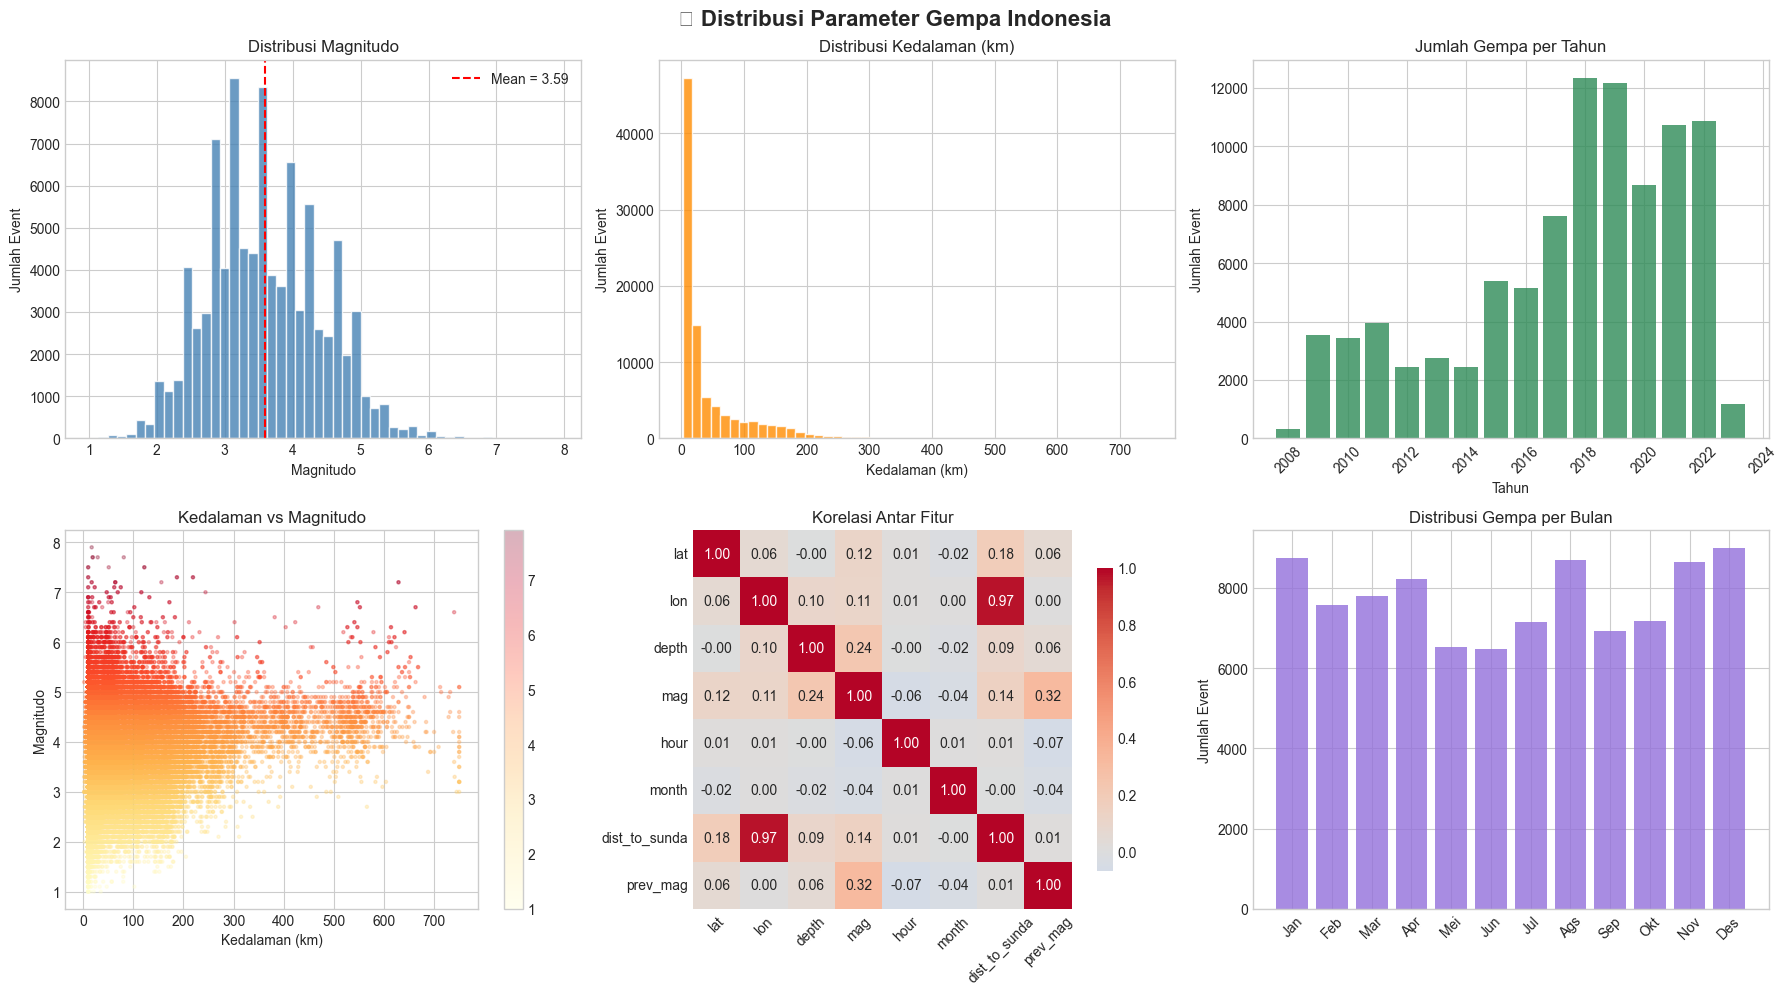

✅ Plot EDA tersimpan sebagai eda_gempa.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Distribusi Parameter Gempa Indonesia', fontsize=16, fontweight='bold')

# 1. Distribusi magnitudo
axes[0,0].hist(df['mag'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribusi Magnitudo')
axes[0,0].set_xlabel('Magnitudo')
axes[0,0].set_ylabel('Jumlah Event')
axes[0,0].axvline(df['mag'].mean(), color='red', linestyle='--', label=f'Mean = {df["mag"].mean():.2f}')
axes[0,0].legend()

# 2. Distribusi kedalaman
axes[0,1].hist(df['depth'], bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Distribusi Kedalaman (km)')
axes[0,1].set_xlabel('Kedalaman (km)')
axes[0,1].set_ylabel('Jumlah Event')

# 3. Gempa per tahun
yearly = df.groupby('year').size()
axes[0,2].bar(yearly.index, yearly.values, color='seagreen', alpha=0.8)
axes[0,2].set_title('Jumlah Gempa per Tahun')
axes[0,2].set_xlabel('Tahun')
axes[0,2].set_ylabel('Jumlah Event')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Depth vs Magnitude
scatter = axes[1,0].scatter(df['depth'], df['mag'], c=df['mag'],
                             cmap='YlOrRd', alpha=0.3, s=5)
axes[1,0].set_title('Kedalaman vs Magnitudo')
axes[1,0].set_xlabel('Kedalaman (km)')
axes[1,0].set_ylabel('Magnitudo')
plt.colorbar(scatter, ax=axes[1,0])

# 5. Heatmap korelasi
corr_cols = ['lat','lon','depth','mag','hour','month','dist_to_sunda','prev_mag']
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': 0.8})
axes[1,1].set_title('Korelasi Antar Fitur')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Gempa per bulan (musiman)
monthly = df.groupby('month').size()
bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Ags','Sep','Okt','Nov','Des']
axes[1,2].bar(range(1,13), monthly.values, color='mediumpurple', alpha=0.8)
axes[1,2].set_title('Distribusi Gempa per Bulan')
axes[1,2].set_xticks(range(1,13))
axes[1,2].set_xticklabels(bulan, rotation=45)
axes[1,2].set_ylabel('Jumlah Event')

plt.tight_layout()
plt.savefig('eda_gempa.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plot EDA tersimpan sebagai eda_gempa.png')

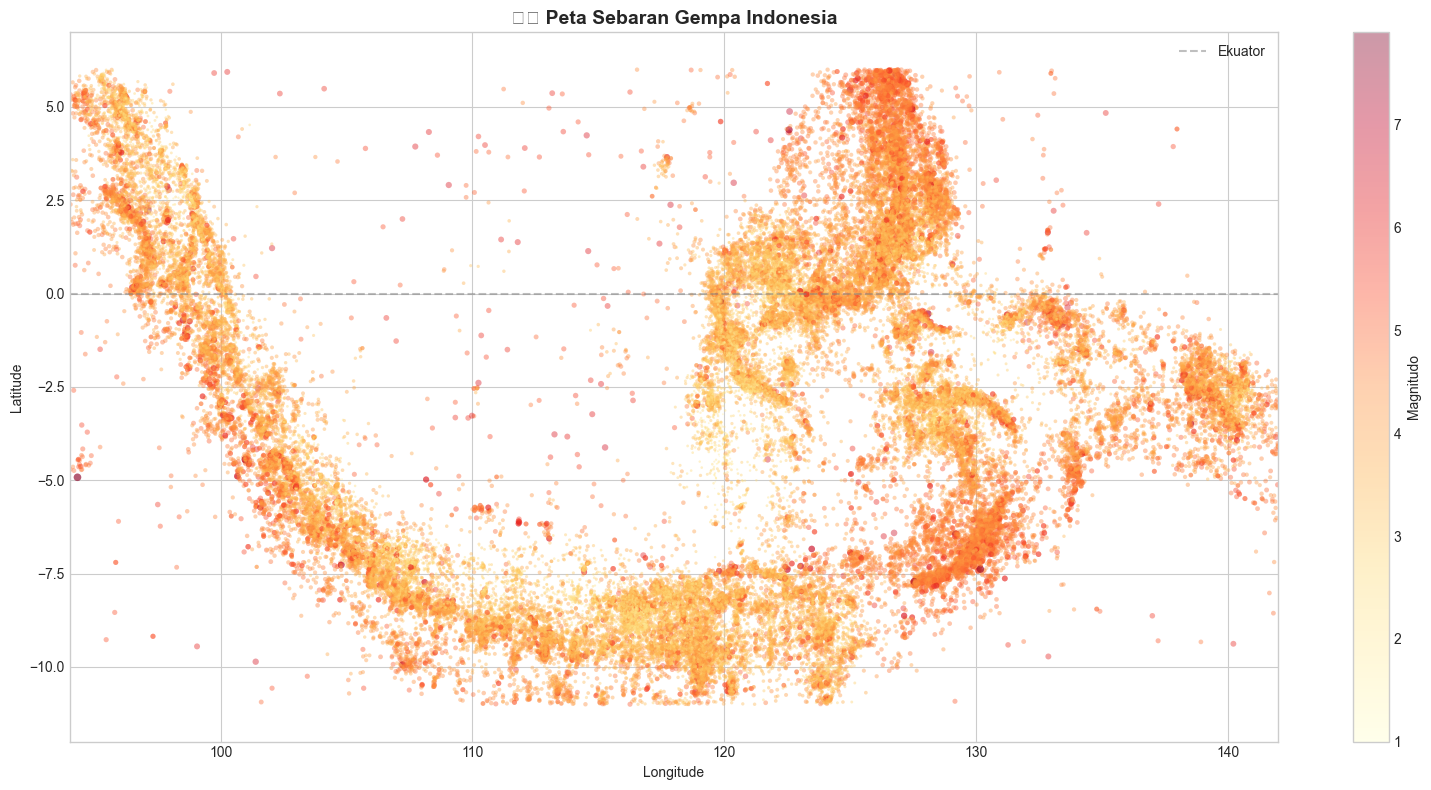

In [15]:
# Peta distribusi spasial gempa
plt.figure(figsize=(16, 8))
sc = plt.scatter(df['lon'], df['lat'],
                 c=df['mag'], cmap='YlOrRd',
                 s=df['mag']**2 * 0.5,
                 alpha=0.4, edgecolors='none')
plt.colorbar(sc, label='Magnitudo')
plt.title('🗺️ Peta Sebaran Gempa Indonesia', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(94, 142)
plt.ylim(-12, 7)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5, label='Ekuator')
plt.legend()
plt.tight_layout()
plt.savefig('peta_gempa.png', dpi=120, bbox_inches='tight')
plt.show()

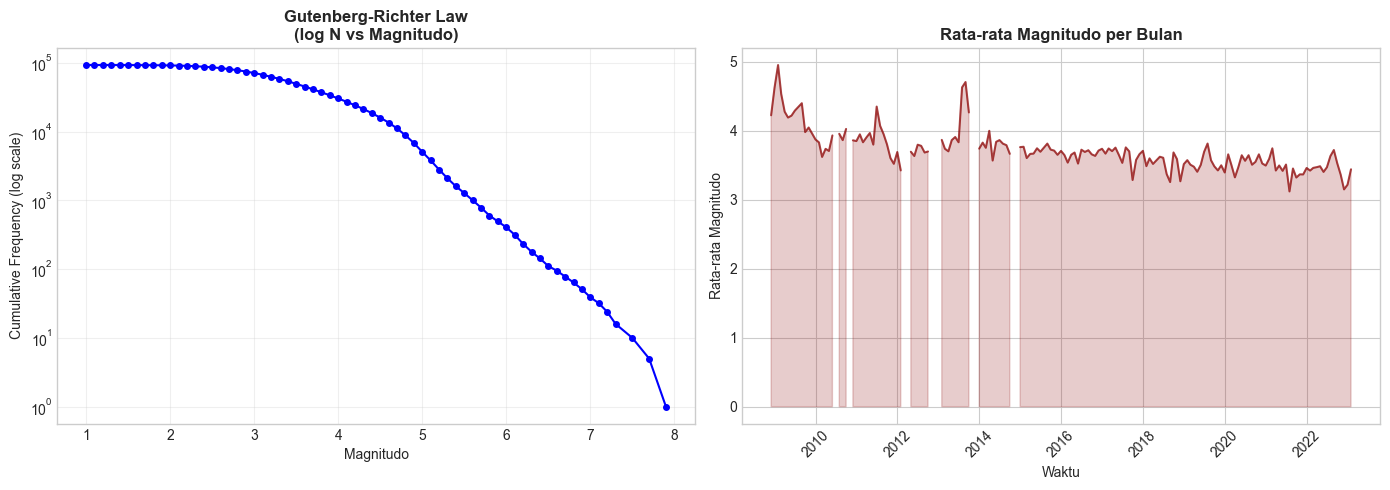

In [16]:
# Gutenberg-Richter Law — distribusi magnitudo seismisitas
mag_counts = df.groupby(df['mag'].round(1)).size().sort_index(ascending=False)
cumulative  = mag_counts.cumsum().sort_index(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(cumulative.index, cumulative.values, 'bo-', markersize=4)
ax1.set_title('Gutenberg-Richter Law\n(log N vs Magnitudo)', fontweight='bold')
ax1.set_xlabel('Magnitudo')
ax1.set_ylabel('Cumulative Frequency (log scale)')
ax1.grid(True, alpha=0.3)

# Time series magnitudo
df_monthly_mag = df.set_index('datetime')['mag'].resample('ME').mean()
ax2.plot(df_monthly_mag.index, df_monthly_mag.values, color='darkred', alpha=0.7)
ax2.fill_between(df_monthly_mag.index, df_monthly_mag.values, alpha=0.2, color='darkred')
ax2.set_title('Rata-rata Magnitudo per Bulan', fontweight='bold')
ax2.set_xlabel('Waktu')
ax2.set_ylabel('Rata-rata Magnitudo')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 🤖 4. Model 1 — Regresi Prediksi Magnitudo

**Target**: Prediksi `mag` (magnitudo) gempa berikutnya  
**Fitur**: lokasi, kedalaman, waktu, aktivitas seismik sebelumnya

In [17]:
# ──────────────────────────────────────────
# 4.1 Persiapan data untuk regresi
# ──────────────────────────────────────────
FEATURES_REG = [
    'lat', 'lon', 'depth',
    'year', 'month', 'hour', 'day_of_week',
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
    'dist_to_sunda', 'depth_cat_num',
    'mag_roll30d_mean', 'mag_roll30d_std', 'count_roll30d',
    'time_since_prev', 'prev_mag', 'prev_depth'
]

TARGET = 'mag'

df_model = df[FEATURES_REG + [TARGET]].dropna()
X = df_model[FEATURES_REG]
y = df_model[TARGET]

# Split train/test (80/20) — gunakan urutan waktu, bukan random!
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Target range: {y.min():.1f} — {y.max():.1f}')

Train: 74,301 | Test: 18,576
Target range: 1.0 — 7.9


In [18]:
# ──────────────────────────────────────────
# 4.2 Training beberapa model regresi
# ──────────────────────────────────────────
models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'          : xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                                          max_depth=6, random_state=42, verbosity=0)
}

results_reg = {}
for name, model in models_reg.items():
    if 'Linear' in name or 'Ridge' in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results_reg[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'model': model, 'y_pred': y_pred}
    print(f'{name:<25} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

print('\n✅ Training selesai!')

Linear Regression         RMSE=0.7558  MAE=0.6046  R²=0.1866
Ridge Regression          RMSE=0.7558  MAE=0.6046  R²=0.1866
Random Forest             RMSE=0.6315  MAE=0.4871  R²=0.4323
XGBoost                   RMSE=0.6291  MAE=0.4873  R²=0.4366

✅ Training selesai!


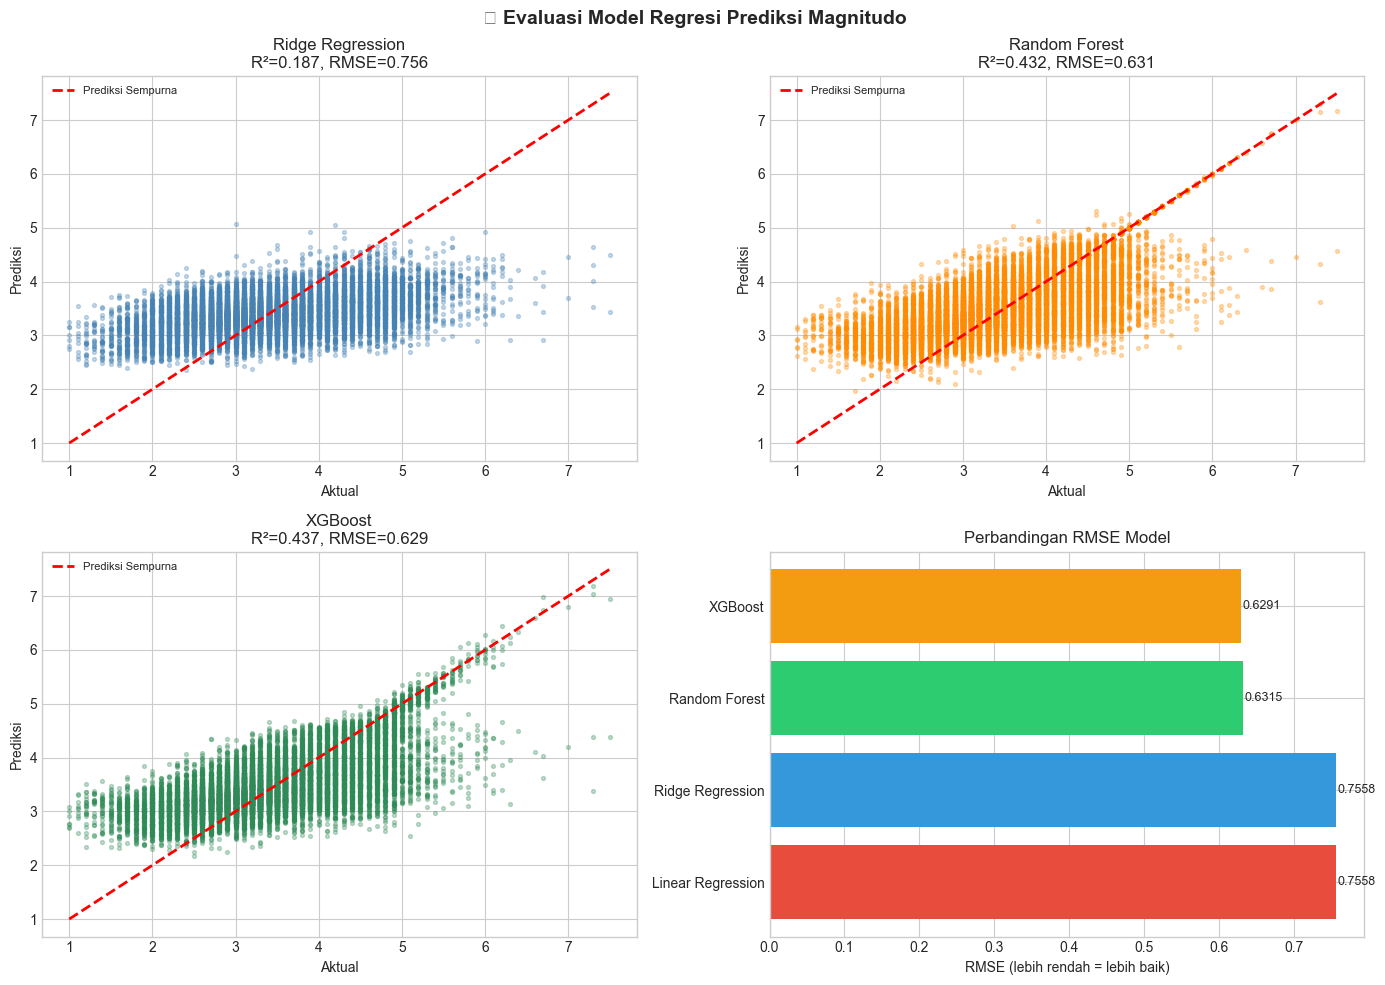

In [19]:
# ──────────────────────────────────────────
# 4.3 Visualisasi hasil regresi
# ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📈 Evaluasi Model Regresi Prediksi Magnitudo', fontsize=14, fontweight='bold')

model_names = [k for k in results_reg if k != 'Linear Regression']
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, name, color in zip(axes.flat[:3], model_names, colors):
    y_pred = results_reg[name]['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.3, s=8, color=color)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Prediksi Sempurna')
    ax.set_title(f'{name}\nR²={results_reg[name]["R²"]:.3f}, RMSE={results_reg[name]["RMSE"]:.3f}')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.legend(fontsize=8)

# Perbandingan RMSE semua model
names = list(results_reg.keys())
rmses = [results_reg[n]['RMSE'] for n in names]
bars  = axes[1,1].barh(names, rmses, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1,1].set_title('Perbandingan RMSE Model')
axes[1,1].set_xlabel('RMSE (lebih rendah = lebih baik)')
for bar, val in zip(bars, rmses):
    axes[1,1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                   f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('hasil_regresi.png', dpi=120, bbox_inches='tight')
plt.show()

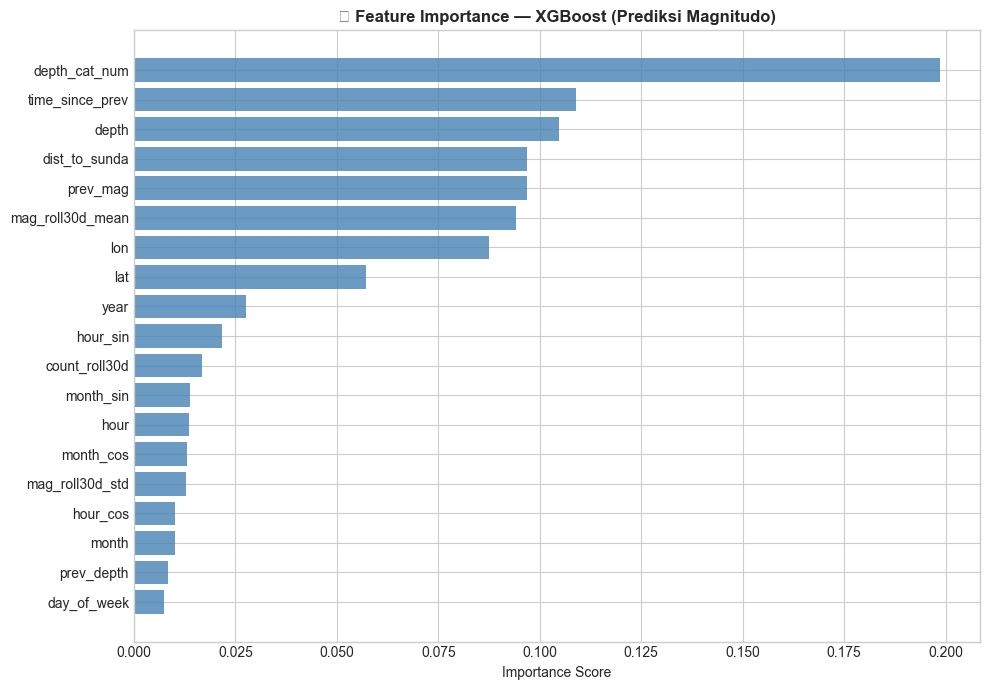


Top 5 fitur terpenting:
depth_cat_num      0.198566
time_since_prev    0.109044
depth              0.104743
dist_to_sunda      0.096845
prev_mag           0.096824
dtype: float32


In [20]:
# ──────────────────────────────────────────
# 4.4 Feature Importance — XGBoost
# ──────────────────────────────────────────
xgb_model = results_reg['XGBoost']['model']
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES_REG)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(importances.index, importances.values, color='steelblue', alpha=0.8)
plt.title('🔍 Feature Importance — XGBoost (Prediksi Magnitudo)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_reg.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 5 fitur terpenting:')
print(importances.sort_values(ascending=False).head())

## 🎯 5. Model 2 — Klasifikasi Tingkat Risiko Gempa

**Target**: Kelas risiko berdasarkan magnitudo
- **Rendah**: mag < 4.0
- **Sedang**: 4.0 ≤ mag < 5.5  
- **Tinggi**: 5.5 ≤ mag < 7.0
- **Ekstrem**: mag ≥ 7.0

In [21]:
# ──────────────────────────────────────────
# 5.1 Buat label klasifikasi risiko
# ──────────────────────────────────────────
def label_risiko(mag):
    if mag < 4.0:   return 'Rendah'
    elif mag < 5.5: return 'Sedang'
    elif mag < 7.0: return 'Tinggi'
    else:           return 'Ekstrem'

df_model['risiko'] = df_model[TARGET].apply(label_risiko)

print('Distribusi kelas risiko:')
dist = df_model['risiko'].value_counts()
for kls, n in dist.items():
    pct = n / len(df_model) * 100
    print(f'  {kls:<10}: {n:>7,} ({pct:.1f}%)')

Distribusi kelas risiko:
  Rendah    :  62,552 (67.3%)
  Sedang    :  29,051 (31.3%)
  Tinggi    :   1,235 (1.3%)
  Ekstrem   :      39 (0.0%)


In [22]:
# ──────────────────────────────────────────
# 5.2 Training classifier
# ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

le = LabelEncoder()
y_cls = le.fit_transform(df_model['risiko'])
X_cls = df_model[FEATURES_REG]

# Tetap split berdasarkan waktu
split_idx = int(len(X_cls) * 0.8)
X_tr, X_te = X_cls.iloc[:split_idx], X_cls.iloc[split_idx:]
y_tr, y_te = y_cls[:split_idx],       y_cls[split_idx:]

# Random Forest dengan class_weight untuk handle imbalanced data
rf_cls = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_cls.fit(X_tr, y_tr)
y_pred_cls = rf_cls.predict(X_te)

acc = accuracy_score(y_te, y_pred_cls)
print(f'\nAkurasi: {acc:.4f} ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_te, y_pred_cls,
                             target_names=le.classes_))


Akurasi: 0.8280 (82.80%)

Classification Report:
              precision    recall  f1-score   support

     Ekstrem       0.00      0.00      0.00         8
      Rendah       0.83      0.97      0.90     14018
      Sedang       0.79      0.39      0.52      4379
      Tinggi       0.96      0.50      0.65       171

    accuracy                           0.83     18576
   macro avg       0.64      0.46      0.52     18576
weighted avg       0.82      0.83      0.80     18576



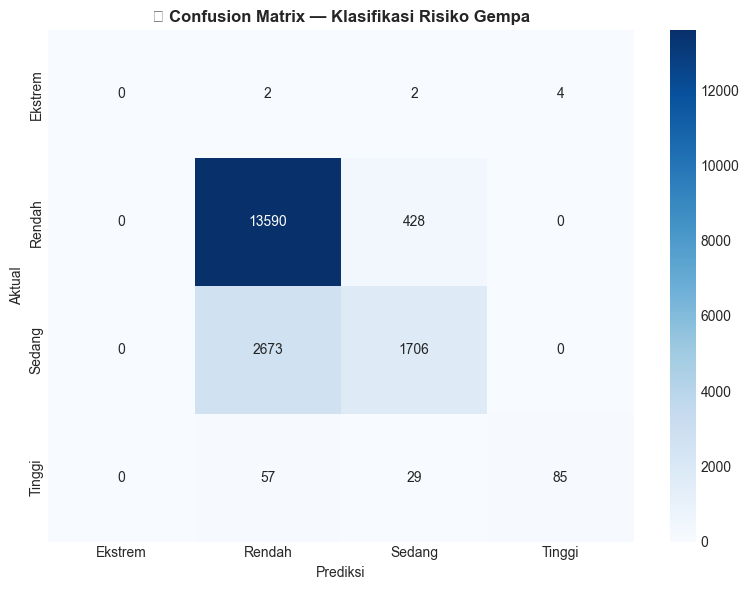

In [23]:
# ──────────────────────────────────────────
# 5.3 Confusion Matrix
# ──────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred_cls)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('🎯 Confusion Matrix — Klasifikasi Risiko Gempa', fontweight='bold')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# ──────────────────────────────────────────
# 5.4 Probability output untuk setiap kelas
# ──────────────────────────────────────────
y_proba = rf_cls.predict_proba(X_te[:5])
proba_df = pd.DataFrame(y_proba, columns=le.classes_)
proba_df.index = [f'Gempa-{i+1}' for i in range(5)]
print('Probabilitas Kelas Risiko (5 sample pertama test set):')
print(proba_df.round(3))

Probabilitas Kelas Risiko (5 sample pertama test set):
         Ekstrem  Rendah  Sedang  Tinggi
Gempa-1      0.0    0.64    0.36     0.0
Gempa-2      0.0    0.65    0.35     0.0
Gempa-3      0.0    0.85    0.15     0.0
Gempa-4      0.0    0.96    0.04     0.0
Gempa-5      0.0    0.90    0.10     0.0


## 🗺️ 6. Model 3 — Clustering Zona Seismik (Unsupervised)

Menemukan zona-zona seismik aktif menggunakan **K-Means** dan **DBSCAN**.

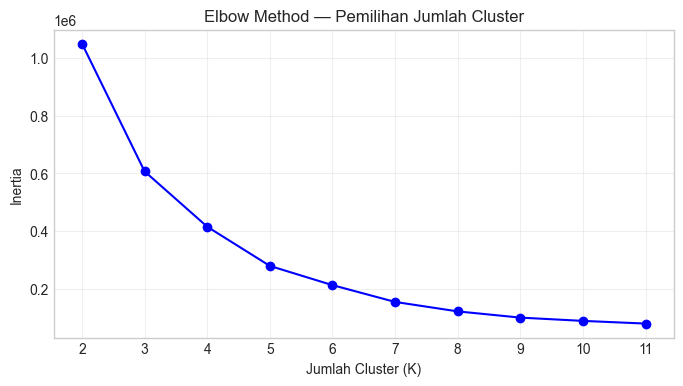

Pilih K di titik siku/elbow!


In [25]:
# ──────────────────────────────────────────
# 6.1 K-Means Clustering
# ──────────────────────────────────────────
# Gunakan sample untuk efisiensi
df_sample = df[['lat', 'lon', 'depth', 'mag']].dropna().sample(n=min(20000, len(df)), random_state=42)

# Elbow method
inertias = []
K_range  = range(2, 12)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_sample[['lat', 'lon']])
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method — Pemilihan Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()
print('Pilih K di titik siku/elbow!')

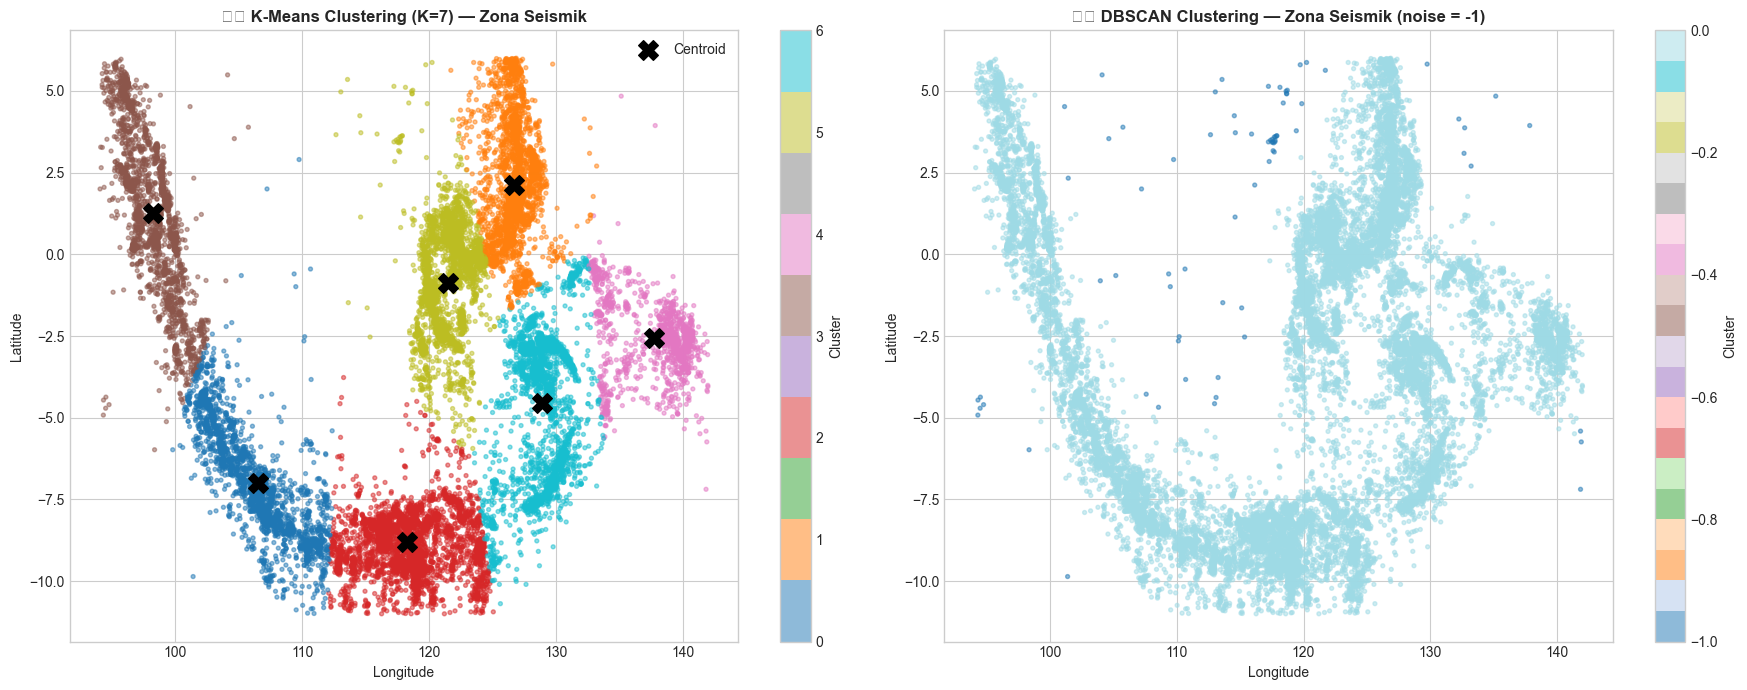

DBSCAN: 1 cluster ditemukan, 75 titik noise


In [26]:
# ──────────────────────────────────────────
# 6.2 Terapkan K-Means dengan K optimal
# ──────────────────────────────────────────
K_OPTIMAL = 7  # Sesuaikan berdasarkan elbow di atas

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_sample['cluster_km'] = kmeans.fit_predict(df_sample[['lat', 'lon']])

# Visualisasi cluster
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# K-Means
scatter1 = ax1.scatter(df_sample['lon'], df_sample['lat'],
                        c=df_sample['cluster_km'], cmap='tab10',
                        s=8, alpha=0.5)
centers = kmeans.cluster_centers_
ax1.scatter(centers[:, 1], centers[:, 0], c='black', s=200,
            marker='X', zorder=5, label='Centroid')
ax1.set_title(f'🗺️ K-Means Clustering (K={K_OPTIMAL}) — Zona Seismik', fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend()
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=50)
df_sample['cluster_db'] = dbscan.fit_predict(df_sample[['lat', 'lon']])

scatter2 = ax2.scatter(df_sample['lon'], df_sample['lat'],
                        c=df_sample['cluster_db'], cmap='tab20',
                        s=8, alpha=0.5)
ax2.set_title('🗺️ DBSCAN Clustering — Zona Seismik (noise = -1)', fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig('clustering_zona_seismik.png', dpi=120, bbox_inches='tight')
plt.show()

n_clusters_db = len(set(df_sample['cluster_db'])) - (1 if -1 in df_sample['cluster_db'].values else 0)
n_noise       = (df_sample['cluster_db'] == -1).sum()
print(f'DBSCAN: {n_clusters_db} cluster ditemukan, {n_noise} titik noise')

In [27]:
# ──────────────────────────────────────────
# 6.3 Profil tiap zona seismik (K-Means)
# ──────────────────────────────────────────
profil = df_sample.groupby('cluster_km').agg(
    jumlah_gempa  = ('mag', 'count'),
    mag_rata      = ('mag', 'mean'),
    mag_max       = ('mag', 'max'),
    depth_rata    = ('depth', 'mean'),
    lat_pusat     = ('lat', 'mean'),
    lon_pusat     = ('lon', 'mean')
).round(2)

print('📋 Profil Zona Seismik:')
print(profil.to_string())

📋 Profil Zona Seismik:
            jumlah_gempa  mag_rata  mag_max  depth_rata  lat_pusat  lon_pusat
cluster_km                                                                   
0                   2582      3.56      7.1       36.89      -7.01     106.50
1                   2909      4.04      7.1       57.55       2.12     126.72
2                   4408      3.34      7.0       48.25      -8.79     118.27
3                   2199      3.66      7.7       37.97       1.26      98.19
4                   1257      3.89      6.6       28.28      -2.56     137.77
5                   3830      3.30      6.6       41.54      -0.88     121.48
6                   2815      3.78      7.3       78.36      -4.55     128.90


## 📡 7. Integrasi Data Sensor BMKG

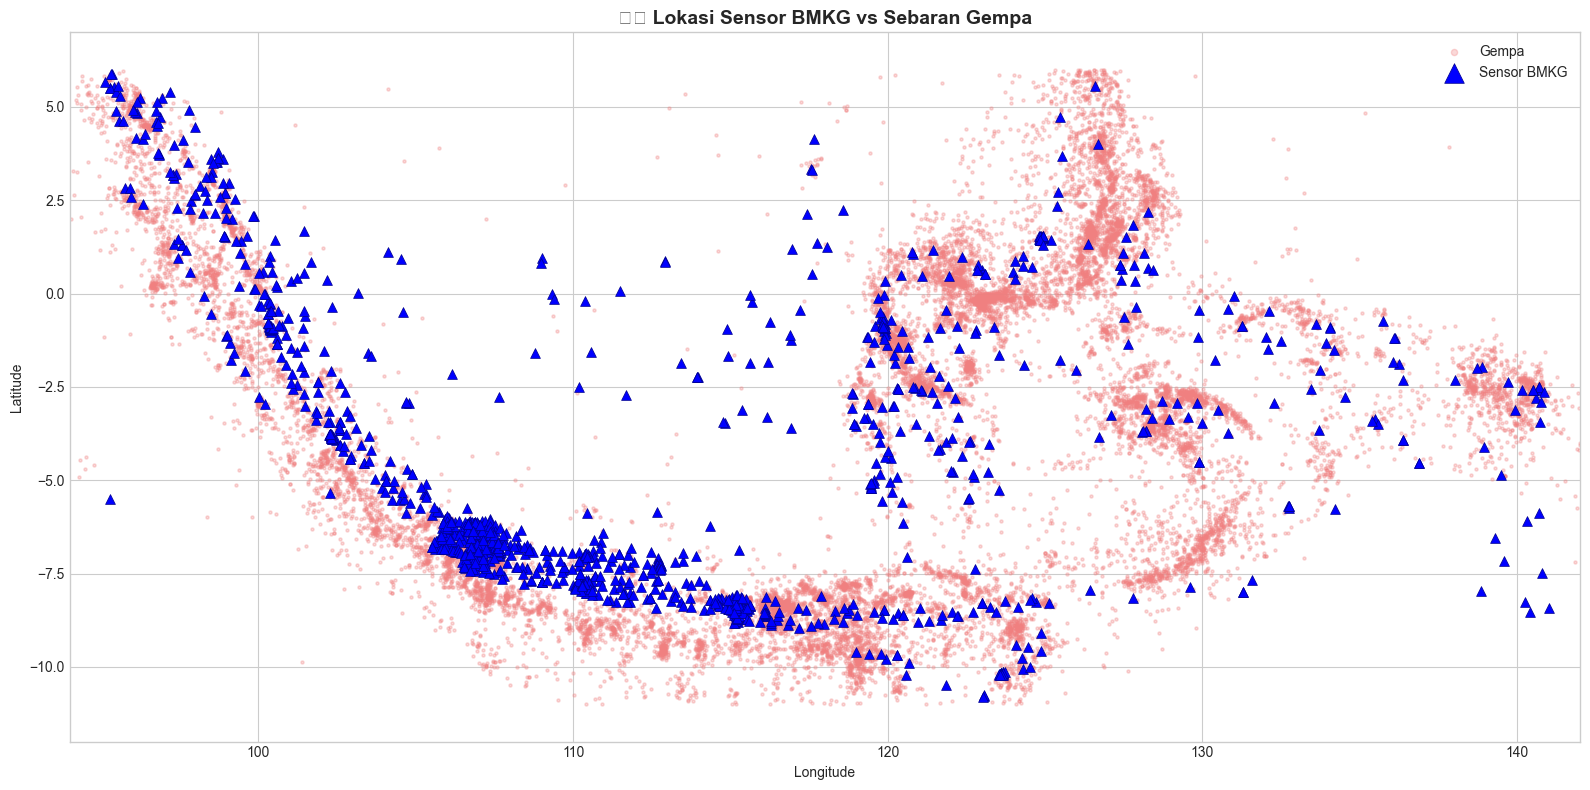

Total sensor BMKG: 1320


In [28]:
# Visualisasi lokasi sensor BMKG vs lokasi gempa
plt.figure(figsize=(16, 8))

# Plot gempa (sample)
plt.scatter(df_sample['lon'], df_sample['lat'],
            c='lightcoral', s=5, alpha=0.3, label='Gempa')

# Plot sensor
plt.scatter(df_sensor['longitude'], df_sensor['latitude'],
            c='blue', s=50, marker='^', zorder=5,
            label='Sensor BMKG', edgecolors='darkblue', linewidths=0.5)

plt.title('🛰️ Lokasi Sensor BMKG vs Sebaran Gempa', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(94, 142)
plt.ylim(-12, 7)
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig('sensor_vs_gempa.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Total sensor BMKG: {len(df_sensor)}')

Distribusi jarak gempa ke sensor terdekat (derajat):
count    92887.000
mean         0.472
std          0.410
min          0.001
25%          0.178
50%          0.366
75%          0.640
max          6.053
dtype: float64


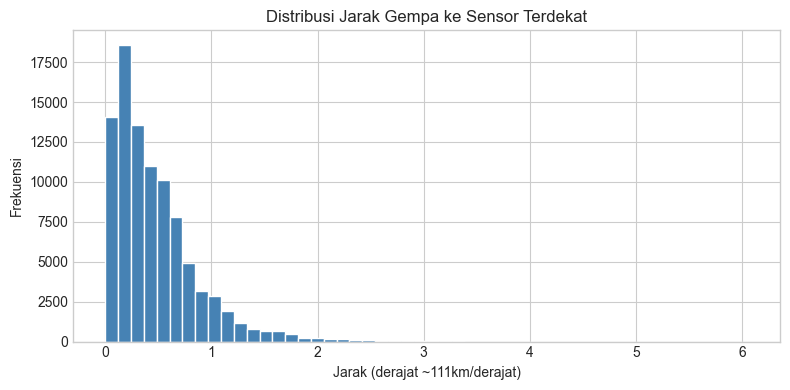

In [29]:
# Hitung jarak gempa ke sensor terdekat
from scipy.spatial import cKDTree

sensor_coords = df_sensor[['latitude', 'longitude']].dropna().values
gempa_coords  = df[['lat', 'lon']].dropna().values

tree = cKDTree(sensor_coords)
dist_to_sensor, _ = tree.query(gempa_coords)

df.loc[df[['lat','lon']].notna().all(axis=1), 'dist_to_nearest_sensor'] = dist_to_sensor

print('Distribusi jarak gempa ke sensor terdekat (derajat):')
print(pd.Series(dist_to_sensor).describe().round(3))

plt.figure(figsize=(8, 4))
plt.hist(dist_to_sensor, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Jarak Gempa ke Sensor Terdekat')
plt.xlabel('Jarak (derajat ~111km/derajat)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

## ⚡ 8. Model Final — XGBoost dengan Hyperparameter Tuning

In [30]:
# ──────────────────────────────────────────
# 8.1 Grid Search XGBoost
# (gunakan subset untuk kecepatan)
# ──────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV

# Subset untuk tuning (agar tidak terlalu lama)
n_tune = min(15000, len(X_train))
X_tune = X_train.iloc[:n_tune]
y_tune = y_train.iloc[:n_tune]

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0)

search = RandomizedSearchCV(
    xgb_base, param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_tune, y_tune)

print(f'\nParameter terbaik: {search.best_params_}')
print(f'Best CV RMSE: {-search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Parameter terbaik: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV RMSE: 0.6513


In [31]:
# ──────────────────────────────────────────
# 8.2 Evaluasi model final
# ──────────────────────────────────────────
best_xgb = search.best_estimator_
best_xgb.fit(X_train, y_train)

y_pred_final = best_xgb.predict(X_test)
rmse_final   = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final    = mean_absolute_error(y_test, y_pred_final)
r2_final     = r2_score(y_test, y_pred_final)

print('=== MODEL FINAL (XGBoost Tuned) ===')
print(f'RMSE : {rmse_final:.4f}')
print(f'MAE  : {mae_final:.4f}')
print(f'R²   : {r2_final:.4f}')
print(f'\nArtinya: prediksi magnitudo rata-rata meleset ±{mae_final:.2f} skala Richter')

=== MODEL FINAL (XGBoost Tuned) ===
RMSE : 0.6321
MAE  : 0.4923
R²   : 0.4311

Artinya: prediksi magnitudo rata-rata meleset ±0.49 skala Richter


In [32]:
# ──────────────────────────────────────────
# 8.3 Simpan model untuk deployment
# ──────────────────────────────────────────
import joblib

joblib.dump(best_xgb,  'model_prediksi_magnitudo.pkl')
joblib.dump(scaler,    'scaler_gempa.pkl')
joblib.dump(rf_cls,    'model_klasifikasi_risiko.pkl')
joblib.dump(le,        'label_encoder_risiko.pkl')
joblib.dump(kmeans,    'model_clustering_zona.pkl')

print('✅ Semua model tersimpan:')
print('  - model_prediksi_magnitudo.pkl')
print('  - model_klasifikasi_risiko.pkl')
print('  - model_clustering_zona.pkl')
print('  - scaler_gempa.pkl')
print('  - label_encoder_risiko.pkl')

✅ Semua model tersimpan:
  - model_prediksi_magnitudo.pkl
  - model_klasifikasi_risiko.pkl
  - model_clustering_zona.pkl
  - scaler_gempa.pkl
  - label_encoder_risiko.pkl


## 🔮 9. Prediksi Gempa Baru (Inference)

Contoh penggunaan model untuk memprediksi gempa baru.

In [33]:
def prediksi_gempa(lat, lon, depth, hour, month, year,
                    prev_mag=4.0, prev_depth=100,
                    mag_mean_30d=4.2, mag_std_30d=0.5, count_30d=150,
                    time_since_prev=3600):
    """
    Prediksi magnitudo dan risiko gempa berdasarkan parameter input.
    
    Parameters
    ----------
    lat, lon       : Koordinat episenter
    depth          : Kedalaman (km)
    hour, month    : Waktu kejadian
    year           : Tahun
    prev_mag       : Magnitudo gempa sebelumnya
    mag_mean_30d   : Rata-rata magnitudo 30 hari terakhir di area
    
    Returns
    -------
    dict berisi prediksi magnitudo dan kelas risiko
    """
    ref_lat, ref_lon = -3.0, 102.0
    dist_sunda   = np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2)
    depth_cat    = 0 if depth < 60 else (1 if depth < 300 else 2)
    month_sin    = np.sin(2 * np.pi * month / 12)
    month_cos    = np.cos(2 * np.pi * month / 12)
    hour_sin     = np.sin(2 * np.pi * hour / 24)
    hour_cos     = np.cos(2 * np.pi * hour / 24)

    features = np.array([[lat, lon, depth,
                           year, month, hour, 0,
                           month_sin, month_cos, hour_sin, hour_cos,
                           dist_sunda, depth_cat,
                           mag_mean_30d, mag_std_30d, count_30d,
                           time_since_prev, prev_mag, prev_depth]])

    mag_pred    = best_xgb.predict(features)[0]
    risiko_pred = le.inverse_transform(rf_cls.predict(features))[0]
    risiko_prob = rf_cls.predict_proba(features)[0]
    zona        = kmeans.predict(np.array([[lat, lon]]))[0]

    return {
        'magnitudo_prediksi': round(float(mag_pred), 2),
        'kelas_risiko'      : risiko_pred,
        'probabilitas_risiko': dict(zip(le.classes_, risiko_prob.round(3))),
        'zona_seismik'      : int(zona)
    }


# ── Contoh 1: Gempa di Lombok
hasil1 = prediksi_gempa(lat=-8.5, lon=116.5, depth=10, hour=14, month=8, year=2024)
print('📍 Lokasi: Lombok')
for k, v in hasil1.items():
    print(f'   {k}: {v}')

print()

# ── Contoh 2: Gempa di Aceh
hasil2 = prediksi_gempa(lat=4.5, lon=95.3, depth=25, hour=22, month=12, year=2024)
print('📍 Lokasi: Aceh')
for k, v in hasil2.items():
    print(f'   {k}: {v}')

📍 Lokasi: Lombok
   magnitudo_prediksi: 3.59
   kelas_risiko: Rendah
   probabilitas_risiko: {'Ekstrem': np.float64(0.0), 'Rendah': np.float64(0.54), 'Sedang': np.float64(0.45), 'Tinggi': np.float64(0.01)}
   zona_seismik: 2

📍 Lokasi: Aceh
   magnitudo_prediksi: 3.81
   kelas_risiko: Rendah
   probabilitas_risiko: {'Ekstrem': np.float64(0.0), 'Rendah': np.float64(0.51), 'Sedang': np.float64(0.46), 'Tinggi': np.float64(0.03)}
   zona_seismik: 3


## 📋 10. Ringkasan & Kesimpulan

In [34]:
# Ringkasan performa semua model
summary = pd.DataFrame({
    'Model'   : list(results_reg.keys()),
    'RMSE'    : [results_reg[n]['RMSE'] for n in results_reg],
    'MAE'     : [results_reg[n]['MAE']  for n in results_reg],
    'R²'      : [results_reg[n]['R²']   for n in results_reg],
}).set_index('Model').round(4)

summary.loc['XGBoost (Tuned)'] = [rmse_final, mae_final, r2_final]
summary['R²'] = summary['R²'].round(4)

print('='*60)
print('📊 RANGKUMAN PERFORMA MODEL REGRESI MAGNITUDO')
print('='*60)
print(summary.to_string())
print()
print(f'Akurasi Klasifikasi Risiko: {acc*100:.2f}%')
print(f'Zona Seismik Terdeteksi   : {K_OPTIMAL} zona (K-Means)')
print('='*60)
print()
print('⚠️  CATATAN PENTING:')
print('   Model ini BUKAN untuk prediksi kapan gempa akan terjadi.')
print('   Gunakan untuk:')
print('   ✓ Estimasi magnitudo berdasarkan pola historis')
print('   ✓ Identifikasi zona berisiko tinggi')
print('   ✓ Mitigasi bencana dan perencanaan tata ruang')

📊 RANGKUMAN PERFORMA MODEL REGRESI MAGNITUDO
                       RMSE       MAE      R²
Model                                        
Linear Regression  0.755800  0.604600  0.1866
Ridge Regression   0.755800  0.604600  0.1866
Random Forest      0.631500  0.487100  0.4323
XGBoost            0.629100  0.487300  0.4366
XGBoost (Tuned)    0.632109  0.492268  0.4311

Akurasi Klasifikasi Risiko: 82.80%
Zona Seismik Terdeteksi   : 7 zona (K-Means)

⚠️  CATATAN PENTING:
   Model ini BUKAN untuk prediksi kapan gempa akan terjadi.
   Gunakan untuk:
   ✓ Estimasi magnitudo berdasarkan pola historis
   ✓ Identifikasi zona berisiko tinggi
   ✓ Mitigasi bencana dan perencanaan tata ruang
